In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pickle


import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, savefig, close
import matplotlib.font_manager as fm
import itertools

import taurex
import xarray as xr
import os
import pandas as pd
import astropy

from taurex.cache import OpacityCache, CIACache
OpacityCache().set_opacity_path('./xsec/')
CIACache().set_cia_path('./cia/')

from taurex.temperature import TemperatureFile
from taurex.chemistry import TaurexChemistry
from taurex.chemistry import ConstantGas

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar

from taurex.model import EmissionModel, TransmissionModel
from taurex.pressure import SimplePressureProfile

from taurex.contributions import AbsorptionContribution
from taurex.contributions import CIAContribution
from taurex.contributions import RayleighContribution

from taurex.binning import FluxBinner

from scipy.optimize import curve_fit, brentq


Numba not installed, using numpy instead


In [2]:
def bindown_single(w1, d1, w2, d2, output, noise, eclipses):
    wf = (w1 + w2) / 2
    df = (w2 + d2/2) - (w1 - d1/2)

    photogrid = np.array([[wf], [df]])

    fb2 = FluxBinner(photogrid[0], photogrid[1])

    # returns wavelength, value, and error
    wl, val, err, *_ = fb2.bindown(
        output[0], output[1],
        error=noise/np.sqrt(eclipses)
    )

    return w1, w2, wl[0], val[0], err[0], df

def make_next_level_points(results):
    """
    results: list of (w1, w2, wl, val, err, df)
             length must be even
    returns: list of (w1, d1, w2, d2)
    """

    assert len(results) % 2 == 0

    new_points = []

    for i in range(0, len(results), 2):
        left_bin  = results[i]
        right_bin = results[i + 1]

        # left edge of combined bin
        w1 = left_bin[2] - left_bin[5] / 2
        # right edge of combined bin
        w2 = right_bin[2] + right_bin[5] / 2

        width = w2 - w1

        new_points.append((w1, width, w2, width))

    return new_points

def bindown_multiple(output, noise, wlgrid, fpfs, eclipses, name, *new_points):
    all_results = []

    for (w1, d1, w2, d2) in new_points:
        out_i = bindown_single(w1, d1, w2, d2, output, noise, eclipses)
        all_results.append(out_i)

    return all_results

def create_point(w1, w2):
    wb1 = wb[np.argmin(np.abs(wl - w1))]
    wb2 = wb[np.argmin(np.abs(wl - w2))]
    point = (w1, wb1, w2, wb2)
    return point

In [3]:
# do this for one example planet for which we have a good nightside detection, then we can loop over all planets and all eclipse numbers to get a more complete picture of the nightside detection capabilities of JWST for USP planets.
# planet datasets

planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
planet_masses = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44] #Earth masses
planet_distances = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012] #AU
planet_period = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55] #days
planet_radius = [1.627, 1.510, 1.242, 1.277, 1.166, 1.397, 1.620, 1.496] #Earth radii
planet_transit = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours

star_temperature = [5261,4570,3381,4850,4440,5342,4884,4914] #Kelvin
star_radius = [0.872,0.681,0.246,0.731,0.678,0.856,0.793,0.746] #Solar radii
star_metallicity = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04] #[Fe/H]
star_logg = [4.5, 4.6, 4.9, 4.6, 4.6, 4.5, 4.5, 4.6]
star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3] #Gyr

In [4]:
# Input parameters

name = planet_names[3] # <- input planet name
mass = planet_masses[planet_names.index(name)] #Earth masses
distance = planet_distances[planet_names.index(name)] #AU
period = planet_period[planet_names.index(name)] #days
radius = planet_radius[planet_names.index(name)] #Earth radii
#convert to Jupiter mass and radius
mass_jup = mass / 317.8
transit = planet_transit[planet_names.index(name)] #hours

star_temp = star_temperature[planet_names.index(name)] #Kelvin
star_rad = star_radius[planet_names.index(name)] #Solar radii
metallicity = star_metallicity[planet_names.index(name)] #[Fe/H]
logg = star_logg[planet_names.index(name)]
age = star_age[planet_names.index(name)] #Gyr

#star spectra
star = PhoenixStar(temperature=star_temp, radius=star_rad, metallicity=metallicity, phoenix_path='Phoenix/')

#binning and noise
binning = False #binning on or off
sigma = 1 #sigma level for error bars 

#binning points
new_point9 = (4.305457, 0.28225, 4.5973, 0.3014)
new_point10 = (4.908865, 0.322, 5.24157, 0.344)

new_point11 = (5.59683967, 0.367, 5.97618103, 0.391)
new_point12 = (6.38, 0.418, 6.814, 0.447)

new_points = [new_point9, new_point10, new_point11, new_point12]

In [5]:
def planet_spectra(wavelength, temperature):

    h = 6.62607015e-34
    c = 299792458
    k = 1.380649e-23

    wl_m = wavelength * 1e-6

    # planet Planck
    Bp = (2*h*c**2) / (wl_m**5 * (np.exp(h*c/(wl_m*k*temperature)) - 1))

    # star Planck (same spectral variable)
    Bs = (2*h*c**2) / (wl_m**5 * (np.exp(h*c/(wl_m*k*star_temp)) - 1))

    r_ratio = ((radius_jup * astropy.constants.R_jup.value)**2) / ((star_rad * astropy.constants.R_sun.value)**2)

    return r_ratio * Bp / Bs

In [6]:
#save all simulation folders in each planet folder
for folder in os.listdir(f"PLANETS/{name}/"):
        if os.path.isdir(os.path.join(f"PLANETS/{name}/", folder)):
            print(folder)

H20_IW4_0001_S20
H10_IW4_0001_S40


In [7]:
#open nightside_success csv to see ballpark of obs necessary for detection
nightside_success = pd.read_csv(f"nightside_success.csv",index_col=0)
display(nightside_success)

,Planet,Hydrogen Inventory [H oceans],Redox State,Nightside Detected,Number of observations,Surface Pressure [bar],Atmospheric Components,Transit Duration (hours),Integration Time (hours),Orbital Period (hours)
0,HD3167,H10,IW4,True,15,10.902882,"SO2, H2O",1.61,345.60,23.04
1,HD3167,H20,IW4,True,13,301.889080,"CO2, N2",1.61,299.52,23.04
2,K2141,H20,IW4,True,8,169.221367,"SO2, H2O",0.94,53.76,6.72
3,K2141,H30,IW2,True,8,16.028394,"SO2, S2",0.94,53.76,6.72
4,LHS1478,H05,IW0,True,10000,317.212366,"H2O, S2",0.71,468000.00,46.80
5,LHS1478,H05,IW4,True,10000,2693.216197,"CO2, H2O",0.71,468000.00,46.80
6,TOI1416,H10,IW0,True,30,4.994660,"H2, H2O",1.50,720.00,24.00
7,TOI1416,H10,IW4,True,49,55.970885,"CO2, SO2",1.50,1176.00,24.00
8,TOI1416,H20,IW0,True,35,437.019741,"CO, N2",1.50,840.00,24.00
9,TOI1807,H10,IW0,True,21,153.474293,"CO, N2",0.98,277.20,13.20


In [19]:
folder = 'H20_IW4_0001_S20' # <- input folder name for simulation

#open temperature profile of the terminator for the given simulation
TP = pd.read_csv(f"PLANETS/{name}/{folder}_TP.csv")
P = np.array(TP['Pressure (Pa)']) / 1e5 #convert to bar
T = np.array(TP['Terminator Temperature (K)']) #Kelvin

simulation_folder = os.path.join(f"PLANETS/{name}/", folder)

#set-up directories and paths
outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"

temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                            temp_col=1, press_col=0,
                            temp_units='K', press_units='Pa',
                            delimiter = ',')

atm_file = None
for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
    if file.endswith("atm.nc"):
        atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
        #save filename without extension
        filename = os.path.splitext(atm_file)[0]
        break

ds = xr.open_dataset(atm_file)

#extract gas names
gases = np.array(ds['gases'])
gases = [m.decode().strip() for m in ds["gases"].values]
vmr = np.array(ds['x_gas'])

pressure = np.array(ds['p']) #pressure in Pa
pmax = pressure.max()
pmin = pressure.min()

radius = float(ds['planet_radius']) #planet radius in m
#convert to Jupiter radii
radius_jup = radius / astropy.constants.R_jup.value

#get mixing ratio of each molecule
H2O_x = float(vmr[:, gases.index('H2O')][0])
CO2_x = float(vmr[:, gases.index('CO2')][0])
CH4_x = float(vmr[:, gases.index('CH4')][0])
CO_x = float(vmr[:, gases.index('CO')][0])
NH3_x = float(vmr[:, gases.index('NH3')][0])
N2_x = float(vmr[:, gases.index('N2')][0])
SO2_x = float(vmr[:, gases.index('SO2')][0])
S2_x = float(vmr[:, gases.index('S2')][0])
O2_x = float(vmr[:, gases.index('O2')][0])
H2_x = float(vmr[:, gases.index('H2')][0])
H2S_x = float(vmr[:, gases.index('H2S')][0])

#define chemistry
chemistry = TaurexChemistry(fill_gases=["N2"])

# check that the sum of all vmr is less or equal to 1
total_vmr = H2O_x + CO2_x + CH4_x + CO_x + NH3_x + N2_x + SO2_x + S2_x + O2_x + H2_x + H2S_x
if total_vmr > 1:
    #renormalize the vmr values
    H2O_x = H2O_x / total_vmr
    CO2_x = CO2_x / total_vmr
    CH4_x = CH4_x / total_vmr
    CO_x = CO_x / total_vmr
    NH3_x = NH3_x / total_vmr
    N2_x = N2_x / total_vmr
    SO2_x = SO2_x / total_vmr
    S2_x = S2_x / total_vmr
    O2_x = O2_x / total_vmr
    H2_x = H2_x / total_vmr
    H2S_x = H2S_x / total_vmr

chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

#convert to jupiter masses without mutating input mass
mass_jup = mass / 317.8
#set-up planet in Jupiter masses and radii
planet = Planet(planet_mass=mass_jup, planet_radius= radius_jup, planet_distance=distance)

star = PhoenixStar(temperature=star_temp, radius=star_rad, metallicity=metallicity, phoenix_path='Phoenix/')

#build emission model at the terminator
em_terminator = EmissionModel( 
planet=planet,
temperature_profile=temp_profile_terminator,
chemistry=chemistry,
pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
star=star,
)

em_terminator.add_contribution(AbsorptionContribution())
em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
em_terminator.add_contribution(RayleighContribution())

em_terminator.build()

#wavenumber grid, flux ratio, and transit depth
wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

wlgrid_t = 10000/wngrid_t[::-1]
fpfs_t = fpfs_t[::-1]

#read-in Ariel noise model
if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
    file = f"ARIEL/arielrad_{name}/tier2.csv"

ariel = pd.read_csv(file,skiprows=6)
wl = np.array(ariel['Wavelength [um]'])
wb = np.array(ariel['Bandwidth [um]'])
noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional

# instantiate flux binner with Ariel's wavelength binning
fb = FluxBinner(wl, wb)
output_t = fb.bindown(wlgrid_t, fpfs_t)
wl, val, err, *_ = output_t

locals()[f"T_{name}_{os.path.basename(simulation_folder)}"] = []

#extract star spectrum on the SAME model grid as fpfs_t
star_flux_model = np.asarray(star.spectralEmissionDensity)
star_wl_model = 10000 / np.asarray(wngrid_t)

n_star = min(star_flux_model.size, star_wl_model.size)
star_flux_model = star_flux_model[:n_star]
star_wl_model = star_wl_model[:n_star]

sort_idx = np.argsort(star_wl_model)
star_wl_model = star_wl_model[sort_idx]
star_flux_model = star_flux_model[sort_idx]

output_star = fb.bindown(star_wl_model, star_flux_model)
star_wl_binned, star_flux_binned, star_err, *_ = output_star


def _mean_model_positive(T):
    if T <= 0:
        return 0.0
    return float(np.mean(planet_spectra(wl, T)))


def _temperature_from_mean_flux(mean_flux):
    target = abs(float(mean_flux))
    if np.isclose(target, 0.0):
        return 0.0

    model_max = _mean_model_positive(3000.0)
    if target >= model_max:
        return 3000.0

    return brentq(lambda T: _mean_model_positive(T) - target, 1e-6, 3000.0)


def signed_planet_spectra(wavelength, temperature):
    T_value = float(np.asarray(temperature).item())

    if np.isclose(T_value, 0.0):
        return np.zeros_like(wavelength, dtype=float)

    return np.sign(T_value) * planet_spectra(wavelength, abs(T_value))


#find lowest number of obs before 1-sigma lower limit for temperature is above 0K
for obs in np.arange(5,15,1):
    locals()[f"T_{name}_{os.path.basename(simulation_folder)}"] = []

    sigma_obs = noise / np.sqrt(obs)

    for n in range(1000):
        val_noise = np.random.normal(loc=val, scale=sigma_obs)

        # Shift the noisy spectrum only as a numerical convenience.
        # The same offset is added to the fitted model, so the recovered
        # temperature still corresponds to the unshifted spectrum.
        delta = float(max(0.0, -np.min(val_noise)))
        val_shifted = val_noise + delta

        mean_guess = float(np.mean(val_noise))
        T_guess = _temperature_from_mean_flux(mean_guess)
        if mean_guess < 0:
            T_guess *= -1.0
        if np.isclose(T_guess, 0.0):
            T_guess = -10.0 if mean_guess < 0 else 10.0

        p0 = [T_guess]
        bounds = ([-3000.0], [3000.0])
        try:
            popt, pcov = curve_fit(
                lambda wavelength, temperature: signed_planet_spectra(wavelength, temperature) + delta,
                wl,
                val_shifted,
                p0=p0,
                sigma=sigma_obs,
                absolute_sigma=True,
                bounds=bounds,
            )
            T_true = float(popt[0])
        except (RuntimeError, ValueError):
            T_true = 0.0

        locals()[f"T_{name}_{os.path.basename(simulation_folder)}"].append(T_true)

    temperature_dist = np.array(locals()[f"T_{name}_{os.path.basename(simulation_folder)}"])

    #find mean and std of temperature distribution
    mean_temp = np.mean(temperature_dist)
    std_temp = np.std(temperature_dist)
    median_temp = np.median(temperature_dist)

    #find 1 sigma confidence interval
    q_low_1, q_high_1 = np.percentile(temperature_dist, [15.865, 84.135])

    #find 3 sigma confidence interval
    q_low, q_high = np.percentile(temperature_dist, [0.135, 99.865])

    # find 5 sigma confidence interval
    q_low_5, q_high_5 = np.percentile(temperature_dist, [0.000057, 99.999943])

    print(f"Analysed for {obs} observations. Mean temperature: {mean_temp:.2f} K, 1-sigma lower limit: {q_low_1:.2f} K, 1-sigma upper limit: {q_high_1:.2f} K")

    if q_low_1 > 0:
        print(f"{obs} observations for {name} - {os.path.basename(simulation_folder)}; Mean temperature: {mean_temp:.2f} K, 1-sigma lower limit: {q_low_1:.2f} K, 1-sigma upper limit: {q_high_1:.2f} K")

        break

Analysed for 5 observations. Mean temperature: 635.07 K, 1-sigma lower limit: -496.74 K, 1-sigma upper limit: 1228.77 K
Analysed for 6 observations. Mean temperature: 664.15 K, 1-sigma lower limit: -452.51 K, 1-sigma upper limit: 1216.90 K
Analysed for 7 observations. Mean temperature: 677.62 K, 1-sigma lower limit: -39.53 K, 1-sigma upper limit: 1192.74 K
Analysed for 8 observations. Mean temperature: 732.03 K, 1-sigma lower limit: 0.00 K, 1-sigma upper limit: 1178.04 K
Analysed for 9 observations. Mean temperature: 728.85 K, 1-sigma lower limit: 0.00 K, 1-sigma upper limit: 1162.34 K
Analysed for 10 observations. Mean temperature: 763.75 K, 1-sigma lower limit: 181.19 K, 1-sigma upper limit: 1158.66 K
10 observations for TOI431 - H20_IW4_0001_S20; Mean temperature: 763.75 K, 1-sigma lower limit: 181.19 K, 1-sigma upper limit: 1158.66 K


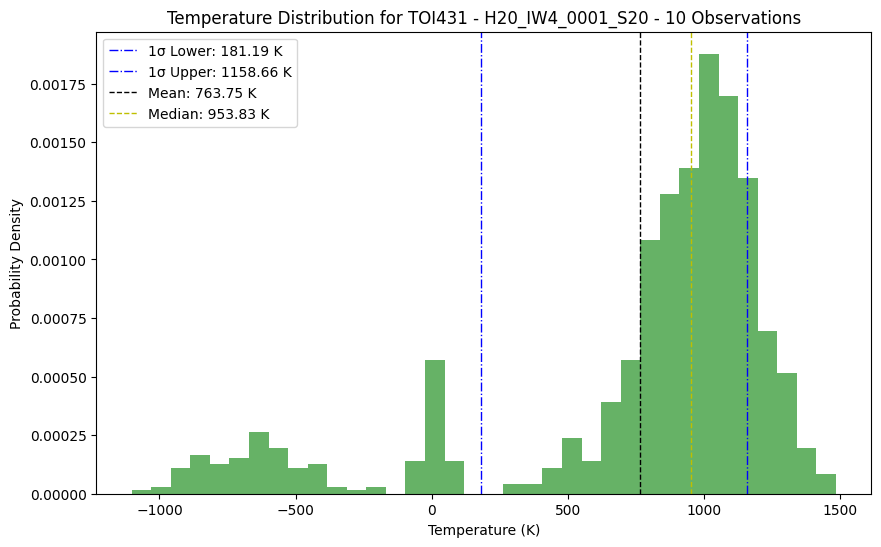

In [20]:
fig = figure(figsize=(10, 6))
plt.hist(temperature_dist, bins='auto', density=True, alpha=0.6, color='g')

#1sigma confidence interval
plt.axvline(q_low_1, color='b', linestyle='dashdot', linewidth=1, label=f'1σ Lower: {q_low_1:.2f} K')
plt.axvline(q_high_1, color='b', linestyle='dashdot', linewidth=1, label=f'1σ Upper: {q_high_1:.2f} K')

plt.axvline(mean_temp, color='k', linestyle='dashed', linewidth=1,label=f'Mean: {mean_temp:.2f} K')
plt.axvline(median_temp, color='y', linestyle='dashed', linewidth=1,label=f'Median: {median_temp:.2f} K')


plt.xlabel('Temperature (K)')
plt.ylabel('Probability Density')
plt.title(f'Temperature Distribution for {name} - {os.path.basename(simulation_folder)} - {obs} Observations')
#plt.xlim(-100, q_high_5)
plt.legend()
plt.show()

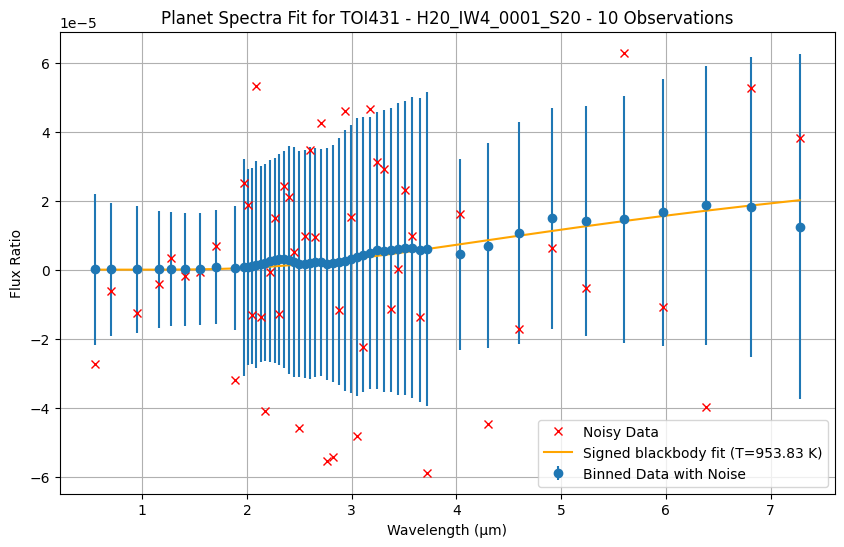

In [21]:
#show the fit of the planet spectra with the mean temperature
plt.figure(figsize=(10, 6))
plt.errorbar(wl, val, yerr=noise/np.sqrt(obs), fmt='o', label='Binned Data with Noise')
plt.plot(wl,val_noise, 'x', label='Noisy Data', color='red')

plt.plot(wl, signed_planet_spectra(wl, median_temp), label=f'Signed blackbody fit (T={median_temp:.2f} K)', color='orange')

plt.xlabel('Wavelength (µm)')
plt.ylabel('Flux Ratio')
plt.title(f'Planet Spectra Fit for {name} - {os.path.basename(simulation_folder)} - {obs} Observations')
plt.grid()
plt.legend()
plt.show()

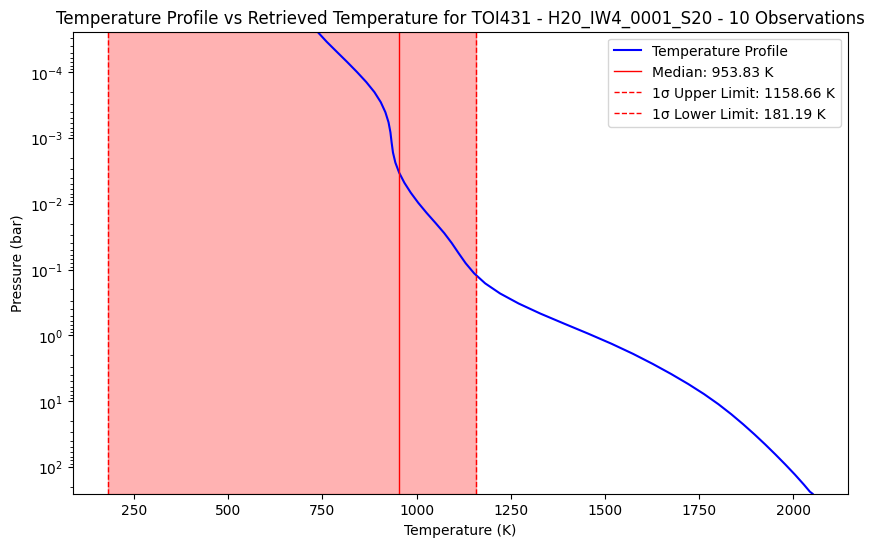

In [22]:
#compare retrieved temperature to the true temperature from the model
fig = figure(figsize=(10, 6))
frame = fig.add_subplot(1, 1, 1)

frame.plot(T,P, label='Temperature Profile', color='blue')
frame.axvline(median_temp, color='red', linewidth=1, label=f'Median: {median_temp:.2f} K')
frame.axvline(q_high_1, color='red', linestyle='dashed', linewidth=1, label=f'1σ Upper Limit: {q_high_1:.2f} K')
frame.axvline(q_low_1, color='red', linestyle='dashed', linewidth=1, label=f'1σ Lower Limit: {q_low_1:.2f} K')
#shaded region for 1 sigma confidence interval
frame.fill_betweenx(P, q_low_1, q_high_1, color='red', alpha=0.3)

frame.invert_yaxis()
frame.set_ylim(P.max(), P.min())
frame.set_xlabel('Temperature (K)')
frame.set_ylabel('Pressure (bar)')
frame.set_title(f'Temperature Profile vs Retrieved Temperature for {name} - {os.path.basename(simulation_folder)} - {obs} Observations')
frame.legend()
frame.set_yscale('log')

show()



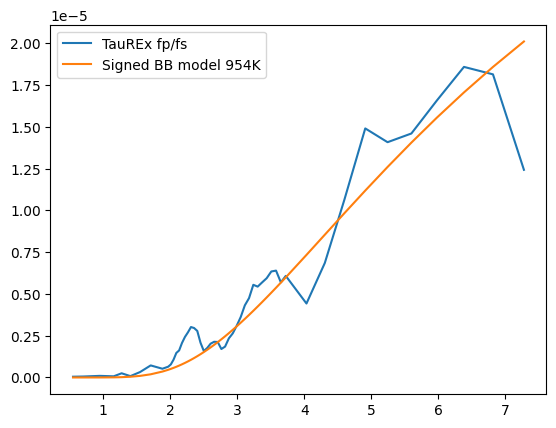

In [23]:
plt.plot(wl, val, label="TauREx fp/fs")
plt.plot(wl, signed_planet_spectra(wl, median_temp), label=f"Signed BB model {median_temp:.0f}K")
#plt.yscale('log')
plt.legend()

In [24]:
#open blackbody_nightside.csv and save results in a dataframe
results_df = pd.read_csv("blackbody_nightside.csv",index_col=0)

In [25]:
#save results in dataframe, storing mean, std, and confidence intervals for each number of observations for corresponding planet name and simulation folder in a new row
results_df.loc[results_df.index.max() + 1] = {
    'Planet': name,
    'Simulation': os.path.basename(simulation_folder),
    'Surface Pressure': pmax / 1e5, #convert Pa to bar
    'Observations with bb fit': obs,
    'Mean Temperature': mean_temp,
    'Median Temperature': median_temp,
    '1-sigma Lower': q_low_1,
    '1-sigma Upper': q_high_1}

In [26]:
results_df

,Planet,Simulation,Surface Pressure,Observations with bb fit,Mean Temperature,Median Temperature,1-sigma Lower,1-sigma Upper
3,HD3167,H10_IW4_00001,10.902882,18.0,684.793264,899.046517,4.260118,1078.279651
4,HD3167,H20_IW4_00001,301.889080,15.0,681.030145,879.790166,22.643581,1080.161661
5,LHS1478,H05_IW0_0001,317.212366,9850.0,232.036301,314.986889,3.034050,347.804389
6,LHS1478,H05_IW4_0001,2693.216197,9850.0,234.972027,317.958710,11.123128,349.009930
12,TOI1416,H10_IW0_00001,4.994660,35.0,604.242009,810.967962,0.000000,998.715337
11,TOI1416,H10_IW4_00001,55.970885,53.0,572.883813,766.109011,0.000000,938.521682
10,TOI1416,H20_IW0_00001,437.019741,37.0,596.799536,796.349503,0.000000,986.541918
15,TOI1807,H5_IW4_00001,13.566413,32.0,628.129859,852.666742,0.000000,1062.576214
13,TOI1807,H10_IW0_00001,153.474293,21.0,666.128679,910.418318,0.000000,1126.003234
8,TOI500,H20_IW2_00001,20.384062,38.0,725.753989,914.841046,42.553907,1131.805116


In [27]:
results_df.to_csv(f"blackbody_nightside.csv", index=True)

In [28]:
nightside_success

,Planet,Hydrogen Inventory [H oceans],Redox State,Nightside Detected,Number of observations,Surface Pressure [bar],Atmospheric Components,Transit Duration (hours),Integration Time (hours),Orbital Period (hours)
0,HD3167,H10,IW4,True,15,10.902882,"SO2, H2O",1.61,345.60,23.04
1,HD3167,H20,IW4,True,13,301.889080,"CO2, N2",1.61,299.52,23.04
2,K2141,H20,IW4,True,8,169.221367,"SO2, H2O",0.94,53.76,6.72
3,K2141,H30,IW2,True,8,16.028394,"SO2, S2",0.94,53.76,6.72
4,LHS1478,H05,IW0,True,10000,317.212366,"H2O, S2",0.71,468000.00,46.80
5,LHS1478,H05,IW4,True,10000,2693.216197,"CO2, H2O",0.71,468000.00,46.80
6,TOI1416,H10,IW0,True,30,4.994660,"H2, H2O",1.50,720.00,24.00
7,TOI1416,H10,IW4,True,49,55.970885,"CO2, SO2",1.50,1176.00,24.00
8,TOI1416,H20,IW0,True,35,437.019741,"CO, N2",1.50,840.00,24.00
9,TOI1807,H10,IW0,True,21,153.474293,"CO, N2",0.98,277.20,13.20


## Results Combined

In [29]:
# Build merge keys from shared Planet + H-inventory + Redox info
ns = nightside_success.copy()
ns['_key'] = ns['Planet'] + '_' + ns['Hydrogen Inventory [H oceans]'] + '_' + ns['Redox State']

rd = results_df.copy()
rd['_key'] = rd['Planet'] + '_' + rd['Simulation'].str.split('_').str[:2].str.join('_')

ns_cols = ['_key', 'Planet', 'Surface Pressure [bar]', 'Atmospheric Components',
           'Hydrogen Inventory [H oceans]', 'Redox State', 'Integration Time (hours)',
           'Number of observations']
rd_cols = ['_key', 'Observations with bb fit', 'Mean Temperature', 'Median Temperature',
           '1-sigma Lower', '1-sigma Upper']

combined_df = ns[ns_cols].merge(rd[rd_cols], on='_key', how='inner').drop(columns='_key')
combined_df

,Planet,Surface Pressure [bar],Atmospheric Components,Hydrogen Inventory [H oceans],Redox State,Integration Time (hours),Number of observations,Observations with bb fit,Mean Temperature,Median Temperature,1-sigma Lower,1-sigma Upper
0,HD3167,10.902882,"SO2, H2O",H10,IW4,345.60,15,18.0,684.793264,899.046517,4.260118,1078.279651
1,HD3167,301.889080,"CO2, N2",H20,IW4,299.52,13,15.0,681.030145,879.790166,22.643581,1080.161661
2,K2141,169.221367,"SO2, H2O",H20,IW4,53.76,8,8.0,832.795583,1075.447271,9.345867,1330.462023
3,K2141,16.028394,"SO2, S2",H30,IW2,53.76,8,8.0,875.997260,1083.199393,410.973486,1343.706663
4,LHS1478,317.212366,"H2O, S2",H05,IW0,468000.00,10000,9850.0,232.036301,314.986889,3.034050,347.804389
5,LHS1478,2693.216197,"CO2, H2O",H05,IW4,468000.00,10000,9850.0,234.972027,317.958710,11.123128,349.009930
6,TOI1416,4.994660,"H2, H2O",H10,IW0,720.00,30,35.0,604.242009,810.967962,0.000000,998.715337
7,TOI1416,55.970885,"CO2, SO2",H10,IW4,1176.00,49,53.0,572.883813,766.109011,0.000000,938.521682
8,TOI1416,437.019741,"CO, N2",H20,IW0,840.00,35,37.0,596.799536,796.349503,0.000000,986.541918
9,TOI1807,153.474293,"CO, N2",H10,IW0,277.20,21,21.0,666.128679,910.418318,0.000000,1126.003234


In [30]:
combined_df.to_csv("combined_nightside_results.csv", index=True)